In [16]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import time

# Pustaka untuk Baseline IBCF & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

# Pustaka untuk Model Usulan (SVD)
from sklearn.decomposition import TruncatedSVD

# Pustaka untuk Visualisasi Hasil (Fase 6)
import matplotlib.pyplot as plt
import seaborn as sns

# Muat data Anda (train.csv)
file_path = 'train.csv'
df = pd.read_csv(file_path)

print("Pustaka dan data berhasil dimuat.")

Pustaka dan data berhasil dimuat.


In [17]:
print("--- 5 Baris Pertama Data ---")
print(df.head())

print("\n--- Informasi Teknis Data ---")
df.info()

# Hitung statistik kunci
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_interactions = len(df)

# Kepadatan data (seberapa banyak matriks terisi)
sparsity = n_interactions / (n_users * n_items)

print(f"\n--- Statistik Data ---")
print(f"Jumlah Pengguna Unik:   {n_users}")
print(f"Jumlah Item (Buku) Unik: {n_items}")
print(f"Jumlah Total Interaksi: {n_interactions}")
print(f"Sparsity Data: {sparsity*100:.4f}% (Sangat sparse)")

--- 5 Baris Pertama Data ---
   user_id     item_id
0        8  0002005018
1        8  074322678X
2        8  0887841740
3        8  1552041778
4        8  1567407781

--- Informasi Teknis Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269764 entries, 0 to 269763
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user_id  269764 non-null  int64 
 1   item_id  269764 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.1+ MB

--- Statistik Data ---
Jumlah Pengguna Unik:   13876
Jumlah Item (Buku) Unik: 123069
Jumlah Total Interaksi: 269764
Sparsity Data: 0.0158% (Sangat sparse)


In [18]:
def apk(actual, predicted, k=10):
    """ Menghitung Average Precision at k (AP@k) untuk satu pengguna. """
    if len(predicted) > k: predicted = predicted[:k]
    score, num_hits = 0.0, 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    if not actual: return 0.0
    return score / min(len(actual), k)

def mapk(actual, predicted, k=10):
    """ Menghitung Mean Average Precision at k (MAP@k) untuk semua pengguna. """
    if not actual or not predicted or len(actual) != len(predicted): return 0.0
    # Ambil rata-rata dari semua skor AP@k
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted) if a])

print("Fungsi metrik apk() dan mapk() telah dibuat.")

Fungsi metrik apk() dan mapk() telah dibuat.


In [19]:
# 1. Membuat ID Kategori (Indeks)
df['user_id_cat'] = df['user_id'].astype("category").cat.codes
df['item_id_cat'] = df['item_id'].astype("category").cat.codes

# 2. Membuat Kamus Penerjemah (Penting untuk evaluasi)
cat_to_item_id = dict(zip(df['item_id_cat'], df['item_id']))
user_id_to_cat = dict(zip(df['user_id'], df['user_id_cat']))

# 3. Membagi Data (80% Latihan, 20% Validasi)
train_df, validation_df = train_test_split(df, 
                                           test_size=0.2, 
                                           random_state=42) # random_state untuk hasil konsisten

print(f"Data latihan: {len(train_df)}, Data validasi: {len(validation_df)}")

Data latihan: 215811, Data validasi: 53953


In [20]:
# 1. Membuat "Kunci Jawaban" (Ground Truth) dari data validasi
validation_truth = validation_df.groupby('user_id')['item_id'].apply(list).to_dict()
# Daftar pengguna yang akan kita uji
validation_users = list(validation_truth.keys()) 

# 2. Membuat "Daftar Filter" (Item di set Latihan)
# Ini digunakan untuk memastikan kita tidak merekomendasikan item yg sudah dilihat
train_items_by_user_str = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

print(f"Jumlah pengguna yang akan diuji: {len(validation_users)}")

# 3. Membuat Matriks Sparse Universal dari data LATIHAN
num_users = df['user_id_cat'].nunique()
num_items = df['item_id_cat'].nunique()

# Input untuk SVD
# Matriks (user, item)
user_item_matrix = csr_matrix((np.ones(len(train_df)), # data (semua bernilai 1)
                               (train_df['user_id_cat'], train_df['item_id_cat'])),
                              shape=(num_users, num_items))

# Input untuk IBCF (adalah kebalikannya)
# Matriks (item, user)
item_user_matrix = user_item_matrix.T.tocsr()

print(f"Bentuk matriks User-Item (untuk SVD): {user_item_matrix.shape}")
print(f"Bentuk matriks Item-User (untuk IBCF): {item_user_matrix.shape}")

Jumlah pengguna yang akan diuji: 11443
Bentuk matriks User-Item (untuk SVD): (13876, 123069)
Bentuk matriks Item-User (untuk IBCF): (123069, 13876)


In [21]:
print("--- [SEGMENT 1] Melatih & Mengevaluasi Model Baseline (IBCF) ---")
start_time = time.time()

# --- 1. Pelatihan (Modeling) ---
print("Menghitung matriks kesamaan item...")
# "Model" IBCF adalah matriks kesamaan ini
item_similarity_matrix = cosine_similarity(item_user_matrix, dense_output=False).tocsr()
print("Pelatihan IBCF selesai.")

# --- 2. Evaluasi ---
predicted_list_ibcf = []
actual_list_ibcf = []

# Fungsi helper HANYA untuk IBCF (membutuhkan item latihan per pengguna)
train_items_by_user_cat = train_df.groupby('user_id_cat')['item_id_cat'].apply(list).to_dict()
def recommend_ibcf(user_cat_id):
    seen_items_cat = train_items_by_user_cat.get(user_cat_id, [])
    if not seen_items_cat: return np.array([])
    # Ambil skor kesamaan & jumlahkan
    similar_scores = item_similarity_matrix[seen_items_cat, :].sum(axis=0)
    return similar_scores.A1

print("Memulai evaluasi IBCF...")
for i, user_id_str in enumerate(validation_users):
    user_cat_id = user_id_to_cat.get(user_id_str)
    if user_cat_id is None: # Pengguna baru (tidak ada di data latih)
        predicted_list_ibcf.append([])
        actual_list_ibcf.append(validation_truth.get(user_id_str, []))
        continue

    # Dapatkan skor mentah
    raw_scores = recommend_ibcf(user_cat_id)
    # Dapatkan indeks item teratas
    top_indices = np.argsort(raw_scores)[::-1]

    # Filter & Terjemahkan
    top_10_recs_str = []
    seen_items_str = train_items_by_user_str.get(user_id_str, set())

    for item_cat in top_indices:
        item_id_str = cat_to_item_id[item_cat]
        if item_id_str not in seen_items_str: # Filtering
            top_10_recs_str.append(item_id_str)
        if len(top_10_recs_str) >= 10:
            break

    predicted_list_ibcf.append(top_10_recs_str)
    actual_list_ibcf.append(validation_truth[user_id_str])

# --- 3. Hitung Skor ---
mapk_score_ibcf = mapk(actual_list_ibcf, predicted_list_ibcf, k=10)
print(f"Evaluasi IBCF selesai dalam {time.time() - start_time:.2f} detik.")

print("\n" + "="*50)
print(f"SKOR MODEL 1 (IBCF): MAP@10 = {mapk_score_ibcf:.6f}")
print("="*50)

--- [SEGMENT 1] Melatih & Mengevaluasi Model Baseline (IBCF) ---
Menghitung matriks kesamaan item...
Pelatihan IBCF selesai.
Memulai evaluasi IBCF...
Evaluasi IBCF selesai dalam 39.19 detik.

SKOR MODEL 1 (IBCF): MAP@10 = 0.007171


In [22]:
print("\n--- [SEGMENT 2] Melatih Model Usulan (SVD Default) ---")
start_time = time.time()

# 1. Inisialisasi Model
# n_components (k) adalah jumlah faktor laten. Kita pilih 50 sebagai default.
K_DEFAULT = 50
model_svd_default = TruncatedSVD(n_components=K_DEFAULT, random_state=42)

# 2. Latih Model
print(f"Memulai pelatihan SVD (k={K_DEFAULT})...")
# Latih pada matriks (user, item)
# Pertama, fit (latih) modelnya
model_svd_default.fit(user_item_matrix)

# Kemudian, transform matriks pengguna dan dapatkan komponen item
# user_factors = U * Sigma
user_factors_default = model_svd_default.transform(user_item_matrix)
# item_factors = V^T
item_factors_default = model_svd_default.components_

print(f"Bentuk User Factors: {user_factors_default.shape}") # Akan jadi (n_users, 50)
print(f"Bentuk Item Factors: {item_factors_default.shape}") # Akan jadi (50, n_items)

print(f"Pelatihan SVD (Default) selesai dalam {time.time() - start_time:.2f} detik.")


--- [SEGMENT 2] Melatih Model Usulan (SVD Default) ---
Memulai pelatihan SVD (k=50)...
Bentuk User Factors: (13876, 50)
Bentuk Item Factors: (50, 123069)
Pelatihan SVD (Default) selesai dalam 5.50 detik.


In [23]:
print("--- Mengevaluasi Model SVD (Default) ---")
start_time = time.time()

predicted_list_svd_default = []
actual_list_svd_default = []

for i, user_id_str in enumerate(validation_users):
    user_cat = user_id_to_cat.get(user_id_str)
    if user_cat is None: # Pengguna baru
        predicted_list_svd_default.append([])
        actual_list_svd_default.append(validation_truth.get(user_id_str, []))
        continue

    # 1. Dapatkan skor rekomendasi personal
    # Hitung skor: (1, k) @ (k, n_items) -> (1, n_items)
    user_scores = user_factors_default[user_cat] @ item_factors_default

    # 2. Urutkan skor (indeks item)
    top_indices = np.argsort(user_scores)[::-1]

    # 3. Filter dan ambil Top 10
    top_10_recs_str = []
    seen_items_str = train_items_by_user_str.get(user_id_str, set())

    for item_cat in top_indices:
        item_id_str = cat_to_item_id[item_cat] # Terjemahkan kembali
        if item_id_str not in seen_items_str: # Lakukan filtering
            top_10_recs_str.append(item_id_str)
        if len(top_10_recs_str) >= 10:
            break

    # 4. Kumpulkan hasil
    predicted_list_svd_default.append(top_10_recs_str)
    actual_list_svd_default.append(validation_truth[user_id_str])

# --- 5. Hitung Skor ---
mapk_score_svd_default = mapk(actual_list_svd_default, predicted_list_svd_default, k=10)
print(f"Evaluasi selesai dalam {time.time() - start_time:.2f} detik.")

print("\n" + "="*50)
print(f"SKOR MODEL 2 (SVD Default, k={K_DEFAULT}): MAP@10 = {mapk_score_svd_default:.6f}")
print("="*50)

--- Mengevaluasi Model SVD (Default) ---
Evaluasi selesai dalam 177.29 detik.

SKOR MODEL 2 (SVD Default, k=50): MAP@10 = 0.008149


In [24]:
print("\n--- [SEGMENT 3] Melatih Model Usulan (SVD Fine-Tuned) ---")
start_time = time.time()

# 1. Inisialisasi Model dengan Parameter yang Di-Tuning
# Parameter yang di-tuning untuk meningkatkan MAP@10:
K_TUNED = 300           # n_components: Jumlah komponen laten (150 -> 200)
N_ITER_TUNED = 10       # n_iter: Iterasi untuk algoritma (default 5 -> 10)
ALGORITHM_TUNED = 'randomized'  # algorithm: 'randomized' lebih cepat & efisien
TOL_TUNED = 1e-4   # Toleransi konvergensi, lebih kecil lebih presisi

print(f"Parameter Tuned:")
print(f"  - n_components: {K_TUNED} (lebih tinggi = representasi lebih kaya)")
print(f"  - n_iter: {N_ITER_TUNED} (lebih banyak iterasi = konvergensi lebih baik)")
print(f"  - algorithm: {ALGORITHM_TUNED} (lebih efisien untuk sparse matrix)")

model_svd_tuned = TruncatedSVD(
    n_components=K_TUNED,
    n_iter=N_ITER_TUNED,
    algorithm=ALGORITHM_TUNED,
    random_state=42,
    tol=TOL_TUNED
)

# 2. Latih Model
print(f"\nMemulai pelatihan SVD (Tuned) dengan parameter optimal...")
# Latih pada data yang sama
model_svd_tuned.fit(user_item_matrix)

# Transform dan dapatkan faktor-faktor
user_factors_tuned = model_svd_tuned.transform(user_item_matrix)
item_factors_tuned = model_svd_tuned.components_

print(f"Bentuk User Factors: {user_factors_tuned.shape}") # Akan jadi (n_users, 150)
print(f"Bentuk Item Factors: {item_factors_tuned.shape}") # Akan jadi (150, n_items)
print(f"  - tol: {TOL_TUNED} (meningkatkan akurasi konvergensi)")

print(f"Pelatihan SVD (Tuned) selesai dalam {time.time() - start_time:.2f} detik.")


--- [SEGMENT 3] Melatih Model Usulan (SVD Fine-Tuned) ---
Parameter Tuned:
  - n_components: 300 (lebih tinggi = representasi lebih kaya)
  - n_iter: 10 (lebih banyak iterasi = konvergensi lebih baik)
  - algorithm: randomized (lebih efisien untuk sparse matrix)

Memulai pelatihan SVD (Tuned) dengan parameter optimal...
Bentuk User Factors: (13876, 300)
Bentuk Item Factors: (300, 123069)
  - tol: 0.0001 (meningkatkan akurasi konvergensi)
Pelatihan SVD (Tuned) selesai dalam 31.65 detik.


In [25]:
print("--- Mengevaluasi Model SVD (Fine-Tuned) ---")
start_time = time.time()

predicted_list_svd_tuned = []

# 'actual_list' sama dengan sebelumnya (actual_list_svd_default)
actual_list_svd_tuned = actual_list_svd_default

for i, user_id_str in enumerate(validation_users):
    user_cat = user_id_to_cat.get(user_id_str)
    if user_cat is None:
        predicted_list_svd_tuned.append([])
        continue

    # 1. Dapatkan skor rekomendasi personal dari model Tuned
    user_scores = user_factors_tuned[user_cat] @ item_factors_tuned

    # 2. Urutkan skor (indeks item)
    top_indices = np.argsort(user_scores)[::-1]

    # 3. Filter dan ambil Top 10
    top_10_recs_str = []
    seen_items_str = train_items_by_user_str.get(user_id_str, set())

    for item_cat in top_indices:
        item_id_str = cat_to_item_id[item_cat]
        if item_id_str not in seen_items_str:
            top_10_recs_str.append(item_id_str)
        if len(top_10_recs_str) >= 10:
            break

    # 4. Kumpulkan hasil
    predicted_list_svd_tuned.append(top_10_recs_str)

# --- 5. Hitung Skor ---
mapk_score_svd_tuned = mapk(actual_list_svd_tuned, predicted_list_svd_tuned, k=10)
print(f"Evaluasi selesai dalam {time.time() - start_time:.2f} detik.")

print("\n" + "="*50)
print(f"SKOR MODEL 3 (SVD Tuned, k={K_TUNED}): MAP@10 = {mapk_score_svd_tuned:.6f}")
print("="*50)

--- Mengevaluasi Model SVD (Fine-Tuned) ---
Evaluasi selesai dalam 275.79 detik.

SKOR MODEL 3 (SVD Tuned, k=300): MAP@10 = 0.014442



--- [FASE 6] Visualisasi & Kesimpulan Proyek ---
--- Tabel Hasil Perbandingan ---


C:\Users\perak\AppData\Local\Temp\ipykernel_27860\3383843244.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='MAP@10', data=df_hasil, palette=colors)


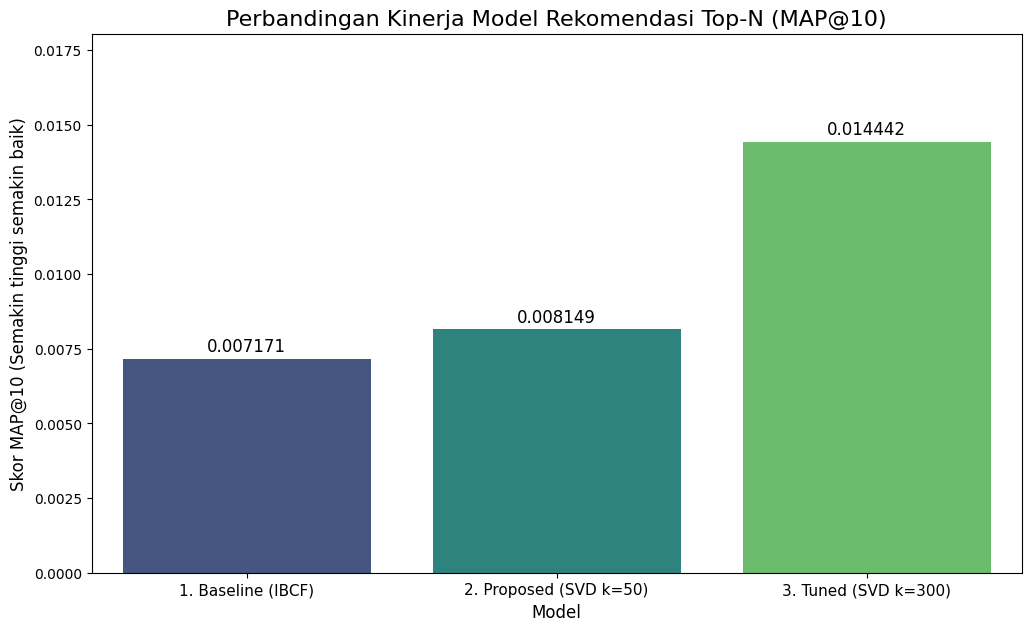

In [26]:
print("\n--- [FASE 6] Visualisasi & Kesimpulan Proyek ---")

# 1. Kumpulkan semua hasil
hasil = {
    'Model': ['1. Baseline (IBCF)', 
              f'2. Proposed (SVD k={K_DEFAULT})', 
              f'3. Tuned (SVD k={K_TUNED})'],
    'MAP@10': [mapk_score_ibcf, 
               mapk_score_svd_default, 
               mapk_score_svd_tuned]
}

df_hasil = pd.DataFrame(hasil)

print("--- Tabel Hasil Perbandingan ---")
# print(df_hasil.to_markdown(index=False)) # Format tabel yang bagus untuk laporan

# 2. Buat Visualisasi (Bar Plot)
plt.figure(figsize=(12, 7))

# Gunakan palet warna yang bagus
colors = sns.color_palette("viridis", n_colors=3)

ax = sns.barplot(x='Model', y='MAP@10', data=df_hasil, palette=colors)

# Tambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12)

plt.title('Perbandingan Kinerja Model Rekomendasi Top-N (MAP@10)', fontsize=16)
plt.ylabel('Skor MAP@10 (Semakin tinggi semakin baik)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, max(df_hasil['MAP@10']) * 1.25) # Beri ruang di atas
plt.xticks(fontsize=11)
plt.show()